# Tugas Analisis Multimedia: **Image (Citra Digital)**

**Mata Kuliah:** Sistem & Teknologi Multimedia  
**Nama:** Harisya Miranti  
**NIM:** 122140049 <br>
**Link Github:** https://github.com/harisya14/Sistem_Teknologi_Multimedia 

---

## Deskripsi Tugas

Tugas ini bertujuan untuk memahami **representasi dasar data citra digital (image)** melalui praktik langsung memuat data, visualisasi komponen warna, serta melakukan analisis spasial sederhana menggunakan berbagai teknik dasar pengolahan citra.

Anda akan bekerja dengan satu atau beberapa gambar (foto diri, objek, atau lingkungan sekitar) untuk:

* Mengamati struktur data piksel dan channel warna (RGB, Grayscale, HSV, dsb.)
* Menganalisis perbedaan hasil visualisasi antar representasi warna
* Melakukan eksplorasi sederhana terhadap transformasi citra (cropping, filtering, edge detection, dll.)
* Menyimpulkan pengaruh setiap tahap pemrosesan terhadap persepsi visual

Fokus tugas ini adalah pada **pemahaman konsep representasi spasial citra digital** dan **interpretasi hasil visualisasi**, **bukan** pada manipulasi kompleks atau penerapan model pembelajaran mesin.

### **Soal 1 — Cropping dan Konversi Warna**

* Ambil sebuah gambar diri Anda (*selfie*) menggunakan kamera atau smartphone.
* Lakukan **cropping secara manual** untuk menghasilkan dua potongan:

  * Cropping **kotak persegi pada area wajah**.
  * Cropping **persegi panjang pada area latar belakang**.
* Resize hasil crop menjadi **920×920 piksel**.
* Konversi gambar menjadi **grayscale** dan **HSV**, lalu tampilkan ketiganya berdampingan.
* Tambahkan **anotasi teks** berisi nama Anda di atas kepala pada gambar hasil crop.

  * Gaya teks (font, warna, posisi, ukuran, ketebalan) **dibebaskan**.
* Jelaskan efek **cropping** dan **perubahan warna** menggunakan **Markdown**.


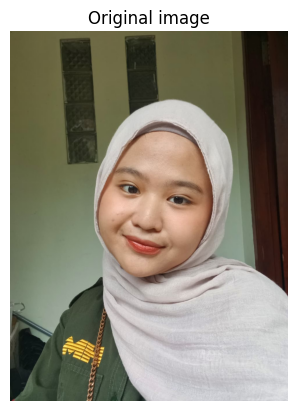

In [50]:
import cv2
import numpy as np
import os
from matplotlib import pyplot as plt

# Soal 1: Load gambar selfie
img_soal1 = cv2.imread('assets_ws4/selfie.jpg')
img_rgb = cv2.cvtColor(img_soal1, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis('off')  
plt.title('Original image')
plt.show()

(np.float64(-0.5), np.float64(199.5), np.float64(299.5), np.float64(-0.5))

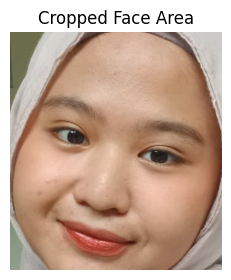

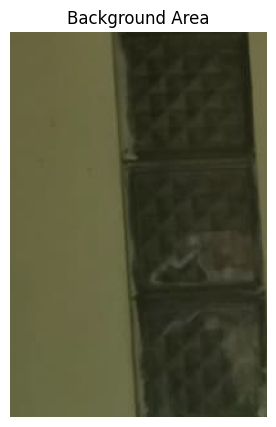

In [51]:
# Cropping area wajah (kotak persegi)
face_crop = img_soal1[350:800, 300:700]  

# Cropping area latar belakang (persegi panjang)
background_crop = img_soal1[150:450, 100:300]  

plt.figure(figsize=(6, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB))
plt.title('Cropped Face Area')
plt.axis('off')

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor (background_crop, cv2.COLOR_BGR2RGB))
plt.title('Background Area')
plt.axis('off')

(np.float64(-0.5), np.float64(919.5), np.float64(919.5), np.float64(-0.5))

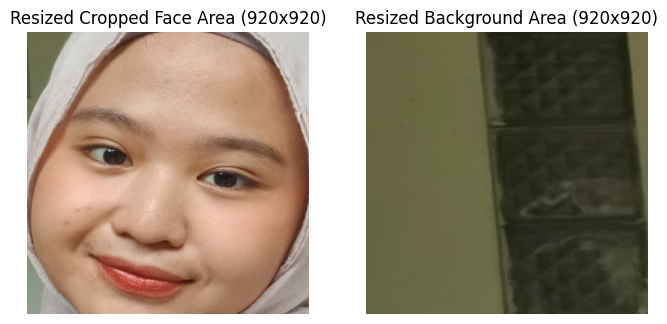

In [52]:
# resize crop images ke 920x920
face_crop_resized = cv2.resize(face_crop, (920, 920))

# resize background crop ke 920x920
background_crop_resized = cv2.resize(background_crop, (920, 920))

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(face_crop_resized, cv2.COLOR_BGR2RGB))
plt.title('Resized Cropped Face Area (920x920)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(background_crop_resized, cv2.COLOR_BGR2RGB))
plt.title('Resized Background Area (920x920)')
plt.axis('off')

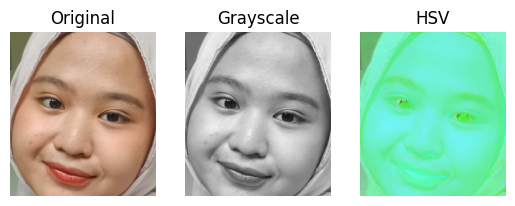

In [78]:
os.makedirs('results_ws4', exist_ok=True)

# Menyimpan hasil
cv2.imwrite('results_ws4/face_crop.jpg', face_crop)
cv2.imwrite('results_ws4/background_crop.jpg', background_crop)

face_gray = cv2.cvtColor(face_crop, cv2.COLOR_BGR2GRAY)
face_hsv = cv2.cvtColor(face_crop, cv2.COLOR_BGR2HSV)

# Menampilkan hasil
plt.subplot(1, 3, 1)
plt.imshow(cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB))
plt.title('Original')
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(face_gray, cmap='gray')
plt.title('Grayscale')
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(cv2.cvtColor(face_hsv, cv2.COLOR_RGB2HSV))
plt.title('HSV')
plt.axis('off')
plt.show()

(np.float64(-0.5), np.float64(399.5), np.float64(449.5), np.float64(-0.5))

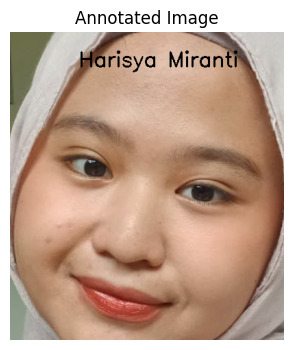

In [54]:
# menambahkan anotasi teks
annotated_img = face_crop.copy()
cv2.putText(annotated_img, 'Harisya Miranti', (100, 50), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 0), 2)

plt.figure(figsize=(8, 4))
plt.imshow(cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB))
plt.title('Annotated Image')
plt.axis('off')

**Penjelasan:**

Pada soal ini, saya melakukan cropping manual pada gambar selfie untuk mendapatkan dua potongan:

1. Pada area wajah (kotak persegi): cropping ini fokus pada bagian wajah dengan dimensi persegi untuk memastikan proporsi yang seimbang.
2. Pada area latar belakang (persegi panjang): Potongan ini mengambil bagian latar belakang dengan dimensi persegi panjang.

Setelah cropping, kedua gambar di-resize ke ukuran 920×920 piksel untuk konsistensi. 

Selanjutnya, gambar cropping area wajah dikonversi warnanya ke grayscale menghilangkan informasi warna RGB, dan dikonversi ke HSV, yaitu representasi warna berdasarkan segmentasi Hue (Jenis Warna), Saturation (Kepekatan Warna), dan Value (Kecerahan).  

### **Soal 2 — Manipulasi Channel Warna RGB**

* Gunakan gambar hasil crop dari Soal 1.
* Konversikan gambar ke ruang warna **RGB**.
* Lakukan manipulasi channel warna dengan cara:

  * **Naikkan intensitas channel merah sebanyak 50 poin** (maksimum 255).
  * **Turunkan intensitas channel biru sebanyak 30 poin** (minimum 0).
* Teknik atau cara menaikkan/menurunkan intensitas **dibebaskan**, asalkan logis dan hasilnya terlihat.
* Gabungkan kembali channel warna dan **simpan gambar hasil modifikasi dalam format `.png`**.
* **Tampilkan histogram per channel (R, G, B)** untuk gambar asli dan hasil modifikasi menggunakan `matplotlib.pyplot.hist`.
* Jelaskan dampak perubahan RGB pada warna gambar dalam sel **Markdown**.


(np.float64(-0.5), np.float64(399.5), np.float64(449.5), np.float64(-0.5))

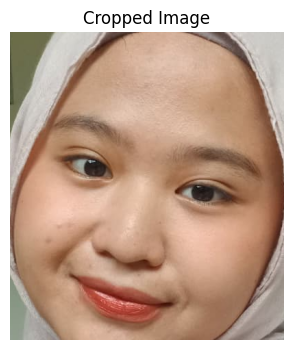

In [55]:
face_crop_rgb = cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB)
plt.figure(figsize=(8, 4))
plt.imshow(face_crop_rgb)
plt.title('Cropped Image')
plt.axis('off')

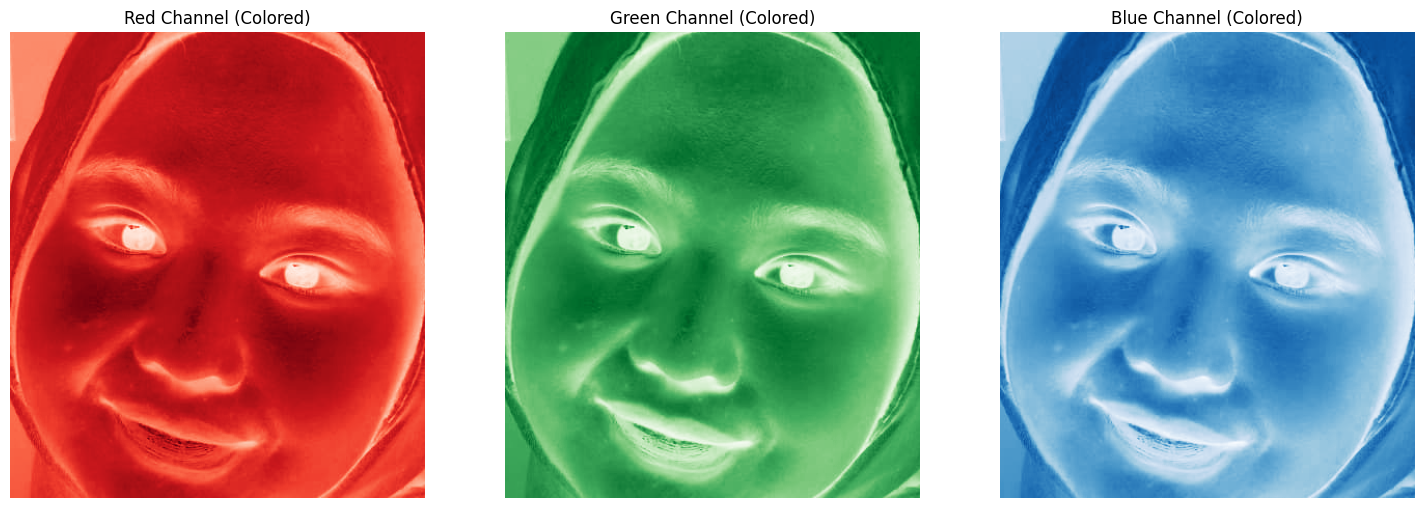

In [56]:
# copy face_crop_rgb untuk split channels
face_split = face_crop_rgb.copy()    

# Split RGB channels dan display individual channel
r_channel, g_channel, b_channel = cv2.split(face_split)

# Membuat visualisasi untuk setiap channel
plt.figure(figsize=(15, 10))

# Display Red Channel
plt.subplot(2, 3, 4)
plt.imshow(r_channel,cmap='Reds')
plt.title('Red Channel (Colored)')
plt.axis('off')

# Display Green Channel
plt.subplot(2, 3, 5)
plt.imshow(g_channel,cmap='Greens')
plt.title('Green Channel (Colored)')
plt.axis('off')

# Display Blue Channel
plt.subplot(2, 3, 6)
plt.imshow(b_channel,cmap='Blues')
plt.title('Blue Channel (Colored)')
plt.axis('off')

plt.tight_layout()
plt.savefig('results_ws4/rgb_channels_split.jpg', dpi=150, bbox_inches='tight')
plt.show()

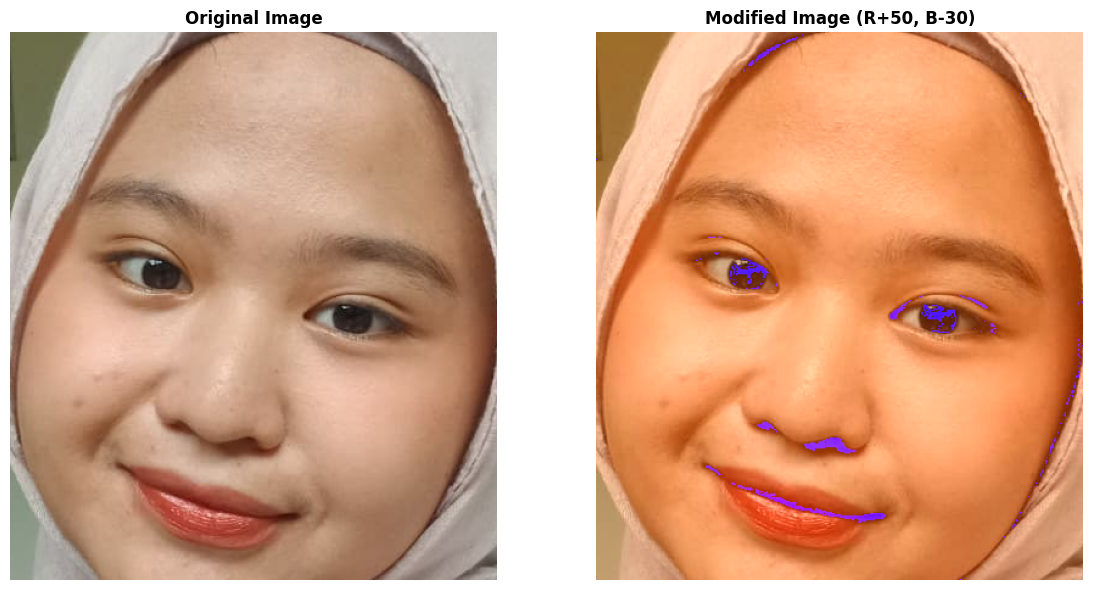

In [57]:
# Manipulasi intensitas dengan clipping
# Channel merah: +50, maksimal 255
r_channel_modified = np.clip(r_channel.astype(np.uint16) + 50, 0, 255).astype(np.uint8)

# Channel biru: -30, minimal 0
b_channel_modified = np.clip(b_channel.astype(np.uint16) - 30, 0, 255).astype(np.uint8)

# Menggabungkan kembali channel yang sudah dimanipulasi
modified_rgb = cv2.merge((r_channel_modified, g_channel, b_channel_modified))

# Menyimpan hasil
cv2.imwrite('results_ws4/face_color_adjusted.png', modified_rgb)

# Menampilkan gambar original vs modified
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.imshow(face_crop_rgb)
plt.title('Original Image', fontsize=12, fontweight='bold')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(modified_rgb)
plt.title('Modified Image (R+50, B-30)', fontsize=12, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.savefig('results_ws4/original_vs_modified.jpg', dpi=150, bbox_inches='tight')
plt.show()

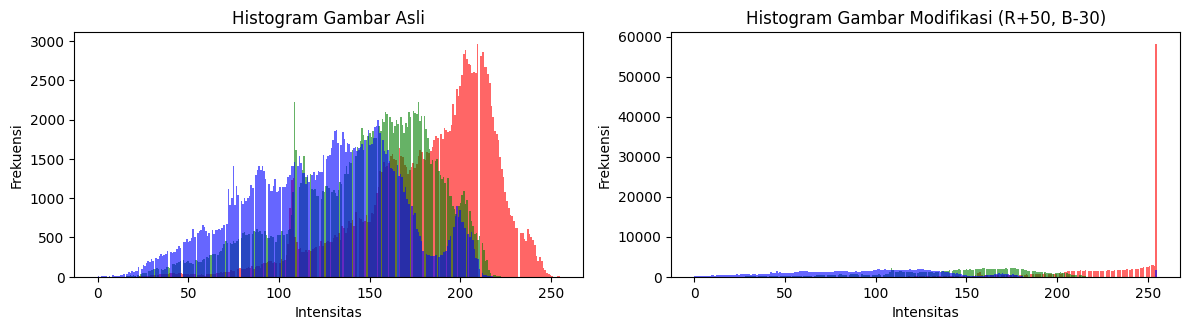

In [58]:
# --- Plot histogram ---
colors = ('r', 'g', 'b')

plt.figure(figsize=(12, 6))

# Histogram untuk gambar asli
plt.subplot(2, 2, 1)
for i, col in enumerate(colors):
    plt.hist(face_crop_rgb[:, :, i].ravel(), bins=256, color=col, alpha=0.6)
plt.title('Histogram Gambar Asli')
plt.xlabel('Intensitas')
plt.ylabel('Frekuensi')

# Histogram untuk gambar hasil modifikasi
plt.subplot(2, 2, 2)
for i, col in enumerate(colors):
    plt.hist(modified_rgb[:, :, i].ravel(), bins=256, color=col, alpha=0.6)
plt.title('Histogram Gambar Modifikasi (R+50, B-30)')
plt.xlabel('Intensitas')
plt.ylabel('Frekuensi')

plt.tight_layout()
plt.show()

**Penjelasan Dampak Perubahan RGB pada Warna Gambar:**

Manipulasi channel RGB dengan menaikkan intensitas merah sebanyak 50 poin dan menurunkan biru sebanyak 30 poin menghasilkan perubahan warna yang sangat signifikan pada gambar. Dari gambar menunjukkan berubah drastis menjadi tone orange/peach yang sangat mencolok pada gambar modified. Saturasi warna meningkat, terutama pada area kulit wajah dan background hijab yang menjadi lebih warm-toned.

Perubahan ini juga menghasilkan warna biru/ungu pada beberapa area seperti mata, hidung, bibir, dan kontur wajah. Hal ini muncul ketika channel merah ditambah 50 poin, banyak piksel mencapai nilai maksimal 255 (saturated), sehingga proporsi RGB menjadi tidak seimbang. Pada area yang seharusnya memiliki highlight atau intensitas tinggi, channel merah terclip ke 255 sedangkan channel biru berkurang 30 poin, menyebabkan channel biru meningkat drastis dan menghasilkan warna biru/ungu yang tidak natural.

Dilihat dari hasil histogram, Histogram gambar original menunjukkan distribusi RGB yang seimbang dengan channel merah berpuncak di sekitar intensitas 200-230. Namun pada histogram gambar modified, channel merah menunjukkan spike/puncak ekstrem di intensitas 255 (ujung kanan histogram) yang menandakan puluhan ribu piksel ter-saturate ke nilai maksimal. Distribusi channel merah bergeser drastis ke kanan dengan hampir semua piksel berada di intensitas tinggi (200-255). Sementara itu, channel biru mengalami pergeseran ke kiri (menurun 30 poin) dan menjadi channel dengan intensitas paling rendah, dengan banyak piksel yang seharusnya biru tua menjadi mendekati nilai 0 (hitam). Channel hijau tetap tidak berubah, namun secara proporsional menjadi lebih "lemah" dibanding channel merah yang ter-boost. 

### **Soal 3 — Deteksi Tepi dan Filter Citra**

* Ambil gambar **objek dengan background bertekstur** (misalnya kain bermotif, jerami, atau batu).
* Terapkan **edge detection (Canny)** dan tampilkan hasilnya.
* Lakukan **thresholding dengan nilai ambang tertentu** (bebas Anda tentukan) agar hanya objek utama yang tersisa.
* Buat **bounding box** di sekitar objek hasil segmentasi (boleh manual atau otomatis).
* Terapkan **filter blur** dan **filter sharpening**, lalu **bandingkan hasil keduanya**.
* Jelaskan bagaimana setiap filter memengaruhi detail gambar dalam format **Markdown**.


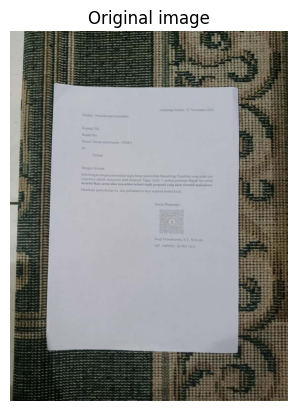

In [59]:
# Soal 3: Load gambar objek dengan background bertekstur
img_soal3 = cv2.imread('assets_ws4/CannyEdge.jpg')
img_rgb_soal3 = cv2.cvtColor(img_soal3, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb_soal3)
plt.axis('off')  
plt.title('Original image')
plt.show()

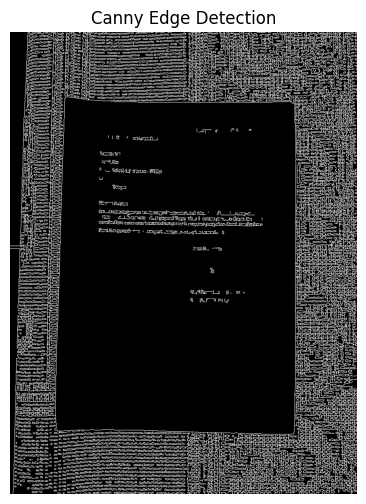

In [60]:
# Convert to grayscale for edge detection
gray_soal3 = cv2.cvtColor(img_soal3, cv2.COLOR_BGR2GRAY)

# Apply Canny edge detection
edges = cv2.Canny(gray_soal3, threshold1=100, threshold2=200)

# Display Canny edges
plt.figure(figsize=(8, 6))
plt.imshow(edges, cmap='gray')
plt.axis('off')
plt.title('Canny Edge Detection')
plt.show()

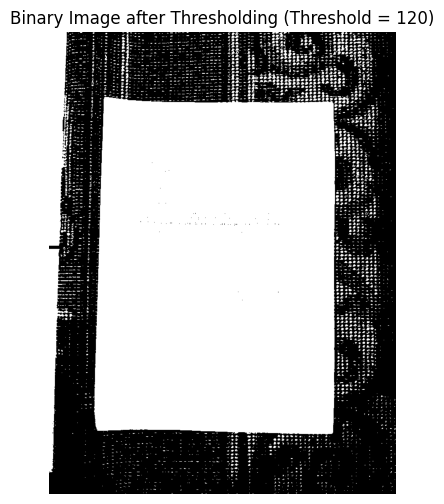

In [61]:
# Thresholding dengan nilai ambang 127 untuk memisahkan objek dari background
# Nilai di atas 127 menjadi putih (255), di bawah menjadi hitam (0)
_, binary_image = cv2.threshold(gray_soal3, 120, 255, cv2.THRESH_BINARY)

plt.figure(figsize=(8, 6))
plt.imshow(binary_image, cmap='gray')
plt.axis('off')
plt.title('Binary Image after Thresholding (Threshold = 120)')
plt.show()

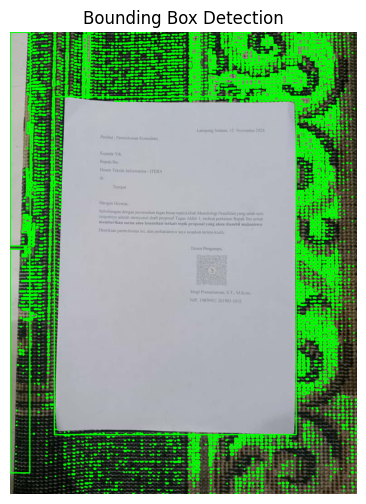

In [62]:
# bounding box detection
contours, _ = cv2.findContours(binary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
boxed_image = img_soal3.copy()
for cnt in contours:
    x, y, w, h = cv2.boundingRect(cnt)
    cv2.rectangle(boxed_image, (x, y), (x + w, y + h), (0, 255, 0), 2)
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(boxed_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Bounding Box Detection')
plt.show()

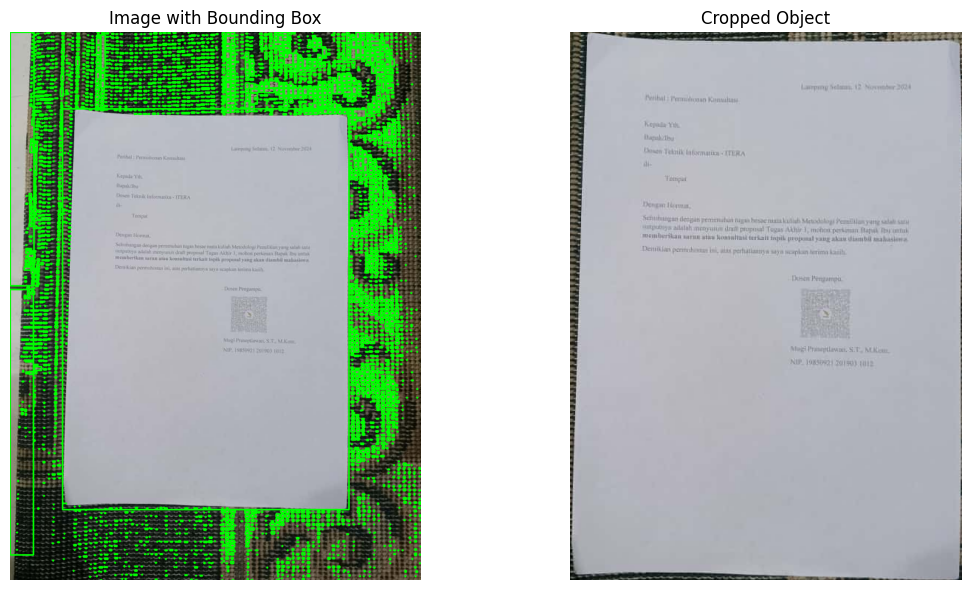

In [63]:
# Crop gambar berdasarkan bounding box terbesar (objek utama)
if len(contours) > 0:
    # Cari kontur dengan area terbesar (objek utama)
    largest_contour = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest_contour)
    
    # Crop gambar original berdasarkan bounding box
    cropped_object = img_soal3[y:y+h, x:x+w]
    
    # Tampilkan hasil cropping
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(cv2.cvtColor(boxed_image, cv2.COLOR_BGR2RGB))
    plt.title('Image with Bounding Box')
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(cropped_object, cv2.COLOR_BGR2RGB))
    plt.title('Cropped Object')
    plt.axis('off')
    
    plt.tight_layout()
    plt.savefig('results_ws4/cropped_object.jpg', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Simpan hasil cropping
    cv2.imwrite('results_ws4/cropped_object.jpg', cropped_object)

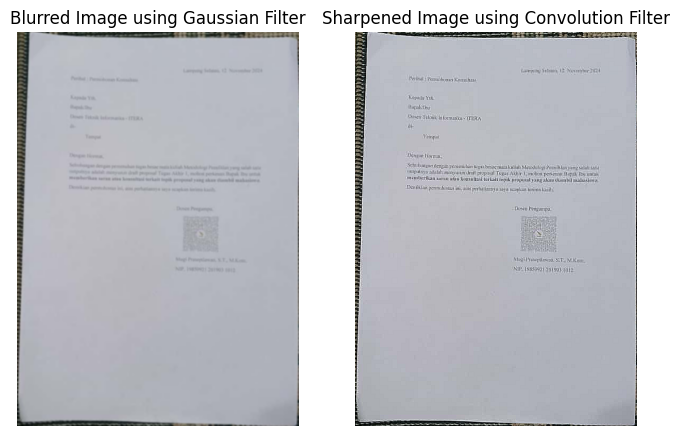

True

In [64]:
# filter blur 
blurred_image = cv2.GaussianBlur(cropped_object, (5, 5), 0)
plt.figure(figsize=(8, 6))
plt.subplot(1, 2, 1)
plt.imshow(cv2.cvtColor(blurred_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Blurred Image using Gaussian Filter')

# filter sharpen
kernel = np.array([[0, -1, 0],
                   [-1, 5,-1],
                   [0, -1, 0]])
sharpened_image = cv2.filter2D(cropped_object, -1, kernel)
plt.subplot(1, 2, 2)
plt.imshow(cv2.cvtColor(sharpened_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Sharpened Image using Convolution Filter')
plt.show()

# save results
cv2.imwrite('results_ws4/blurred_image.jpg', blurred_image)
cv2.imwrite('results_ws4/sharpened_image.jpg', sharpened_image)

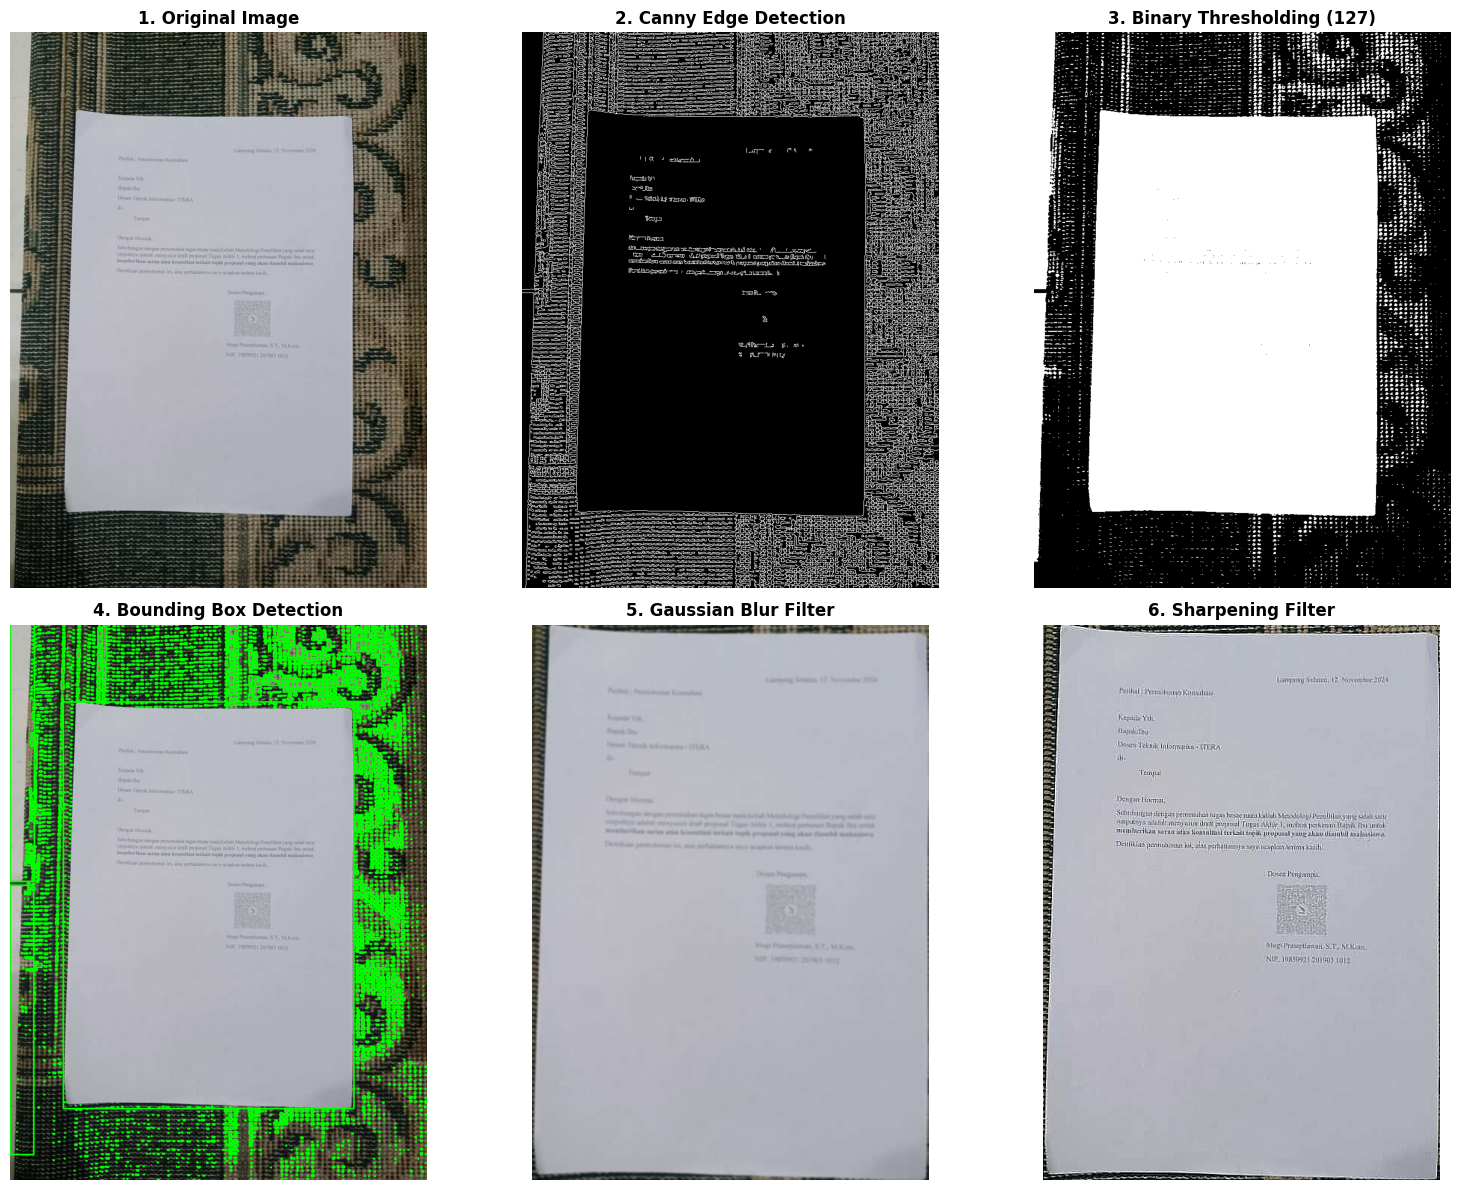

In [65]:
# Visualisasi perbandingan semua tahapan dalam satu grid
fig = plt.figure(figsize=(16, 12))

# Original Image
plt.subplot(2, 3, 1)
plt.imshow(img_rgb_soal3)
plt.title('1. Original Image', fontsize=12, fontweight='bold')
plt.axis('off')

# Canny Edge Detection
plt.subplot(2, 3, 2)
plt.imshow(edges, cmap='gray')
plt.title('2. Canny Edge Detection', fontsize=12, fontweight='bold')
plt.axis('off')

# Thresholding
plt.subplot(2, 3, 3)
plt.imshow(binary_image, cmap='gray')
plt.title('3. Binary Thresholding (127)', fontsize=12, fontweight='bold')
plt.axis('off')

# Bounding Box
plt.subplot(2, 3, 4)
plt.imshow(cv2.cvtColor(boxed_image, cv2.COLOR_BGR2RGB))
plt.title('4. Bounding Box Detection', fontsize=12, fontweight='bold')
plt.axis('off')

# Blur Filter
plt.subplot(2, 3, 5)
plt.imshow(cv2.cvtColor(blurred_image, cv2.COLOR_BGR2RGB))
plt.title('5. Gaussian Blur Filter', fontsize=12, fontweight='bold')
plt.axis('off')

# Sharpen Filter
plt.subplot(2, 3, 6)
plt.imshow(cv2.cvtColor(sharpened_image, cv2.COLOR_BGR2RGB))
plt.title('6. Sharpening Filter', fontsize=12, fontweight='bold')
plt.axis('off')

plt.tight_layout()
plt.savefig('results_ws4/all_steps_comparison.jpg', dpi=150, bbox_inches='tight')
plt.show()

Ketika membandingkan kedua hasil filter secara berdampingan:
- Filter Blur menghasilkan gambar yang lebih smooth dan natural, cocok untuk mengurangi noise, karena blur menghilangkan detail dengan mengaburkan dan meratakan intensitas piksel
- Filter Sharpening menghasilkan gambar yang lebih tajam dan detail, cocok untuk dokumen dan teks. Sharpening memperkuat detail dengan meningkatkan kontras pada tepi dan perbedaan antar piksel.

namun pada gambar yang ditampilkan kedua filter tidak membuat teks lebih terlihat jelas, mungkin karena gambar di crop sehingga kualitas gambar yang ter crop menjadi menurun/terdistrosi. 

### **Soal 4 — Deteksi Wajah dan Filter Digital Kreatif**

* Ambil gambar diri Anda dengan ekspresi wajah **netral**.
* Lakukan **deteksi wajah dan landmark** menggunakan salah satu dari:

  * **MediaPipe**, atau
  * **Dlib**, atau
  * **OpenCV**.
* Buat **overlay filter digital kreatif** karya Anda sendiri, misalnya:

  * topi, kumis, masker, helm, aksesoris, atau bentuk unik lainnya.
  * Filter boleh dibuat dari **gambar eksternal (PNG)** *atau* digambar langsung (misal bentuk lingkaran, garis, poligon, dll).
* Pastikan posisi overlay menyesuaikan **landmark wajah** dengan logis.
* **Gunakan alpha blending sebagai saran** agar hasil tampak lebih natural.
* Tampilkan perbandingan antara **gambar asli** dan **hasil dengan filter**.
* Jelaskan bagaimana Anda menghitung posisi overlay dan tantangan yang dihadapi selama implementasi (gunakan **Markdown**).

In [66]:
import mediapipe as mp

# Initialize MediaPipe Face Detection and Face Mesh
mp_face_detection = mp.solutions.face_detection
mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils
mp_drawing_styles = mp.solutions.drawing_styles

# Konfigurasi Face Mesh
face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=True,      
    max_num_faces=1,             
    refine_landmarks=True,       
    min_detection_confidence=0.5
)

print("✅ MediaPipe Face Mesh berhasil diinisialisasi!")

✅ MediaPipe Face Mesh berhasil diinisialisasi!


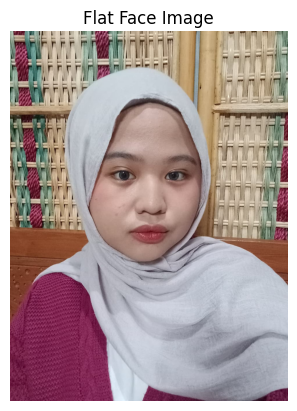

In [67]:
# Soal 4: Load gambar wajah untuk deteksi landmark
image_path_soal4 = 'assets_ws4/flat_face.jpg'
img_soal4 = cv2.imread(image_path_soal4)
if img_soal4 is None:
    raise FileNotFoundError(f"File '{image_path_soal4}' tidak ditemukan!")
image_rgb_soal4 = cv2.cvtColor(img_soal4, cv2.COLOR_BGR2RGB)
image_rgb_soal4 = cv2.cvtColor(img_soal4, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb_soal4)
plt.imshow(image_rgb_soal4)
plt.axis('off')
plt.title('Flat Face Image')
plt.show()

c:\Users\User\OneDrive\Desktop\Sistem_Teknologi_Multimedia\multimedia-uv\lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


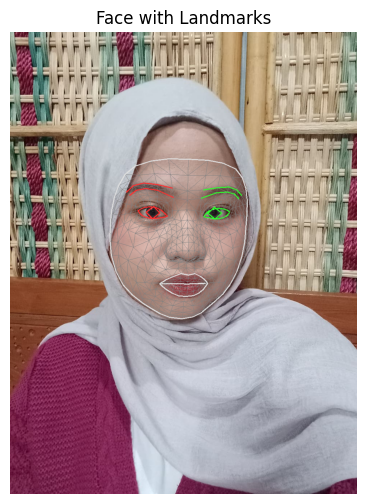

True

In [68]:
# Deteksi landmark wajah
results = face_mesh.process(image_rgb_soal4)

# Salin gambar untuk hasil visualisasi
output_image = img_soal4.copy()

if results.multi_face_landmarks:
    for face_landmarks in results.multi_face_landmarks:
        # Gambar *TITIK* dan *GARIS* menggunakan drawing utilities MediaPipe
        mp_drawing.draw_landmarks(
            image=output_image,
            landmark_list=face_landmarks,
            connections=mp_face_mesh.FACEMESH_TESSELATION,
            landmark_drawing_spec=None,  # Gunakan default titik
            connection_drawing_spec=mp_drawing_styles.get_default_face_mesh_tesselation_style()
        )
        mp_drawing.draw_landmarks(
            image=output_image,
            landmark_list=face_landmarks,
            connections=mp_face_mesh.FACEMESH_CONTOURS,
            landmark_drawing_spec=None,
            connection_drawing_spec=mp_drawing_styles.get_default_face_mesh_contours_style()
        )
        # Opsional: gambar iris (jika refine_landmarks=True)
        mp_drawing.draw_landmarks(
            image=output_image,
            landmark_list=face_landmarks,
            connections=mp_face_mesh.FACEMESH_IRISES,
            landmark_drawing_spec=None,
            connection_drawing_spec=mp_drawing_styles.get_default_face_mesh_iris_connections_style()
        )

else:
    print("Wajah tidak terdeteksi!")

plt.figure(figsize=(6, 6))
plt.imshow(cv2.cvtColor(output_image, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Face with Landmarks')
plt.show()
# simpan hasil
cv2.imwrite("results_ws4/face_with_landmarks.jpg", output_image)


In [69]:
# Create eye patch function
def create_eye_patch(size=(120, 60), color=(20, 20, 20), border_color=(50, 50, 50), strap_color=(80, 80, 80)):
    """Buat eye patch bajak laut secara programatis (tanpa file eksternal)."""
    w, h = size
    patch = np.zeros((h, w, 4), dtype=np.uint8)

    # Ellipse utama
    center = (w // 2, h // 2)
    axes = (int(w * 0.42), int(h * 0.75))
    cv2.ellipse(patch, center, axes, 0, 0, 360, (*color, 255), -1)
    cv2.ellipse(patch, center, axes, 0, 0, 360, (*border_color, 255), 2)

    # Tali horizontal (putus-putus)
    y_strap = h // 2
    for x_start in range(10, w - 20, 12):
        x_end = min(x_start + 6, w - 10)
        cv2.line(patch, (x_start, y_strap), (x_end, y_strap), (*strap_color, 220), 2)

    # Simbol "X" kecil
    pad = 15
    x1, y1 = pad, h // 2 - 8
    x2, y2 = w - pad, h // 2 + 8
    cv2.line(patch, (x1, y1), (x2, y2), (255, 255, 255, 200), 2)
    cv2.line(patch, (x1, y2), (x2, y1), (255, 255, 255, 200), 2)

    return patch

In [86]:
img_path_no4 = "assets_ws4/flat_face.jpg"  
img_no4 = cv2.imread(img_path_no4)
if img_no4 is None:
    raise FileNotFoundError(f"'{img_path_no4}' tidak ditemukan! Cek nama file & folder.")

img_rgb_vis = cv2.cvtColor(img_no4, cv2.COLOR_BGR2RGB)

# Deteksi face mesh
mp_face_mesh = mp.solutions.face_mesh
face_mesh = mp_face_mesh.FaceMesh(
    static_image_mode=True,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5
)

results = face_mesh.process(cv2.cvtColor(img_no4, cv2.COLOR_BGR2RGB))

if not results.multi_face_landmarks:
    raise RuntimeError("❌ Wajah tidak terdeteksi!")

landmarks = results.multi_face_landmarks[0].landmark
h_img_no4, w_img_no4 = img_no4.shape[:2]

print("Landmark terdeteksi!")
print(f"  - Resolusi: {w_img_no4}×{h_img_no4}")
print(f"  - Jumlah landmark: {len(landmarks)}")

Landmark terdeteksi!
  - Resolusi: 960×1280
  - Jumlah landmark: 478


In [ ]:
# Terapkan eye patch pada wajah terdeteksi

def get_xy(idx):
    lm = landmarks[idx]
    return np.array([lm.x * w_img_no4, lm.y * h_img_no4], dtype=np.float32)

# Landmark mata kiri: 33 (kiri), 133 (kanan)
left_eye_left = get_xy(33)
left_eye_right = get_xy(133)
center = (left_eye_left + left_eye_right) / 2
eye_width = np.linalg.norm(left_eye_right - left_eye_left)

# Buat & proses eye patch
eye_patch = create_eye_patch()
ph, pw = eye_patch.shape[:2]
scale = 1.8 * eye_width / pw
new_w, new_h = int(pw * scale), int(ph * scale)
resized_patch = cv2.resize(eye_patch, (new_w, new_h), interpolation=cv2.INTER_CUBIC)

# Rotasi
dx, dy = left_eye_right - left_eye_left
angle = np.degrees(np.arctan2(dy, dx))
M = cv2.getRotationMatrix2D((new_w // 2, new_h // 2), angle, 1.0)
rotated_patch = cv2.warpAffine(
    resized_patch, M, (new_w, new_h),
    flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT, borderValue=(0,0,0,0)
)

# Posisi overlay
x1 = int(center[0] - new_w // 2)
y1 = int(center[1] - new_h // 2)
x2, y2 = x1 + new_w, y1 + new_h

# Batasi ke dalam gambar
x1, y1 = max(0, x1), max(0, y1)
x2, y2 = min(w_img_no4, x2), min(h_img_no4, y2)

patch_cropped = rotated_patch[0:y2-y1, 0:x2-x1]
roi = img_no4[y1:y2, x1:x2]

# Alpha blending
if patch_cropped.shape[2] == 4:
    alpha = patch_cropped[:, :, 3].astype(np.float32) / 255.0
    alpha = np.stack([alpha] * 3, axis=2)
    blended = (1 - alpha) * roi + alpha * patch_cropped[:, :, :3]
    img_no4[y1:y2, x1:x2] = blended.astype(np.uint8)

# Buat layer transparan khusus untuk tali 
line_layer = np.zeros((h_img_no4, w_img_no4, 4), dtype=np.uint8)

# Ambil titik akhir tali
brow_right = get_xy(284)   # alis kanan atas
brow_left = get_xy(139)    # alis kiri atas 

# Titik awal tali: ujung kanan & kiri eye patch
patch_end_x = x1 + new_w - 10
patch_end_y = y1 + new_h // 2

patch_start_x = x1 + 10
patch_start_y = y1 + new_h // 2

# Gambar tali di layer transparan
cv2.line(
    line_layer,
    pt1=(int(patch_end_x), int(patch_end_y)),
    pt2=(int(brow_right[0]), int(brow_right[1])),
    color=(80, 80, 80, 150),  # B, G, R, A
    thickness=2,
    lineType=cv2.LINE_AA
)

cv2.line(
    line_layer,
    pt1=(int(patch_start_x), int(patch_start_y)),
    pt2=(int(brow_left[0]), int(brow_left[1])),
    color=(80, 80, 80, 150),
    thickness=2,
    lineType=cv2.LINE_AA
)

# Ekstrak RGB dan Alpha
rgb = line_layer[:, :, :3]      # BGR
alpha = line_layer[:, :, 3] / 255.0  # 0–1

# Blend ke gambar asli
alpha_expanded = np.expand_dims(alpha, axis=2)
blended_line = (1 - alpha_expanded) * img_no4 + alpha_expanded * rgb
img_no4 = blended_line.astype(np.uint8)


print(f"✅ Eye patch diterapkan!")
print(f"   Rotasi: {angle:.1f}° | Skala: {scale:.2f}× | Posisi: ({x1}, {y1})")


✅ Eye patch diterapkan!
   Rotasi: 10.6° | Skala: 1.23× | Posisi: (321, 467)

   Rotasi: 10.6° | Skala: 1.23× | Posisi: (321, 467)


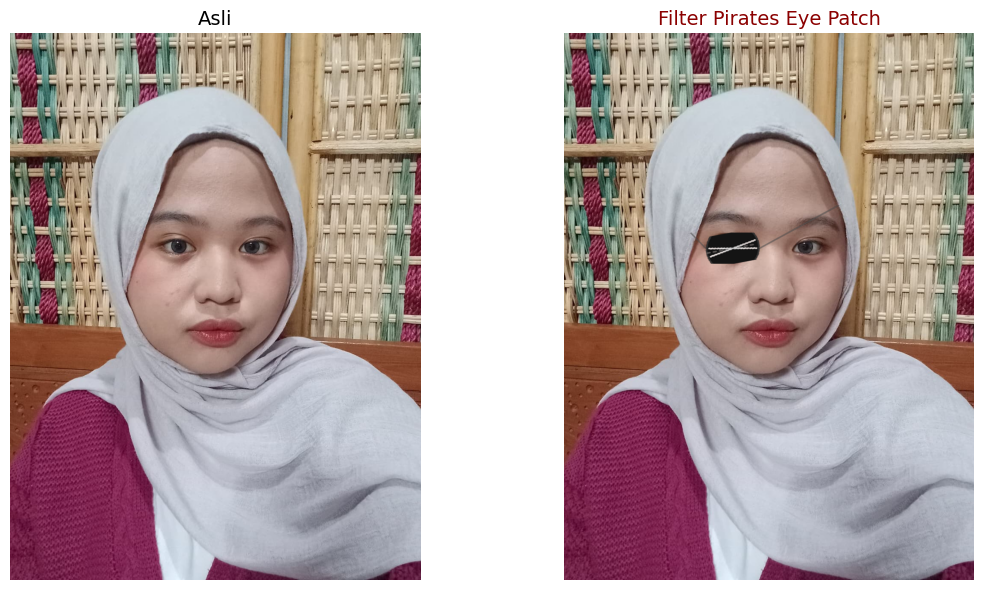

True

In [ ]:
# Konversi hasil ke RGB untuk matplotlib
result_rgb = cv2.cvtColor(img_no4, cv2.COLOR_BGR2RGB)

# Plot side-by-side
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Asli", fontsize=14)
plt.imshow(img_rgb_vis)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Filter Pirates Eye Patch", fontsize=14, color='darkred')
plt.imshow(result_rgb)
plt.axis('off')

plt.tight_layout()
plt.show()

# simpan hasil
cv2.imwrite("results_ws4/face_with_eye_patch.jpg", img_no4)
cv2.imwrite("results_ws4/pirate_comparison.jpg", cv2.hconcat([cv2.cvtColor(img_rgb_vis, cv2.COLOR_RGB2BGR), img_no4]))

**Penjelasan:**

Dalam implementasi filter ini, saya memilih filter berupa eye patch Pirates/bajak laut, saya memanfaatkan MediaPipe Face Mesh untuk mendeteksi 478 titik landmark wajah termasuk kontur mata, alis, hidung, dan bibir. Untuk menempatkan eye patch secara logis, saya memilih mata kiri sebagai acuan dengan menggunakan dua landmark penting: indeks 33 (ujung kiri mata) dan 133 (ujung kanan mata). Dari kedua titik ini, saya hitung pusat mata sebagai rata-rata koordinatnya, lalu lebar mata sebagai jarak antar kedua titik tersebut. Nilai lebar ini digunakan untuk menyesuaikan skala eye patch agar proporsional dengan ukuran mata pada setiap wajah.

Selanjutnya, saya menghitung sudut rotasi dari garis yang menghubungkan titik 33 dan 133 terhadap sumbu horizontal, sehingga eye patch bisa diputar sejalan dengan kemiringan wajah. Setelah itu, saya menempatkan eye patch dengan menyelaraskan pusatnya ke pusat mata, lalu melakukan alpha blending menggunakan channel alpha dari gambar eye patch (atau dari layer transparan) agar hasilnya tampak menyatu dengan kulit, bukan seperti stiker yang terpasang kaku. Tantangan utama yang saya hadapi adalah menyamakan orientasi tali diagonal, karena tali harus mengarah ke alis kanan (landmark 284) dan alis kiri (landmark 139), saya perlu memastikan bahwa titik awal tali tepat di ujung eye patch, bukan di tengah, dan tidak terlalu dekat ke tepi agar tidak terpotong. 

**Soal 5 — Perspektif dan Peningkatan Kualitas Citra**

  * Ambil gambar **objek datar** seperti karya tangan di kertas, tulisan di papan tulis, atau foto produk di meja dengan kondisi pencahayaan atau sudut yang tidak ideal.\n",
  * Lakukan **preprocessing** untuk memperbaiki tampilan agar lebih rapi dan jelas, dengan langkah-langkah:\n",
  * Konversi ke **grayscale**.\n",
  * **Koreksi perspektif (transformasi homografi)** menggunakan **4 titik manual** agar objek terlihat sejajar dan tidak terdistorsi.\n",
  * Terapkan **thresholding adaptif atau Otsu** (pilih salah satu, dan jelaskan alasan pilihan Anda).\n",
  * Tampilkan **setiap tahap pemrosesan dalam satu grid** agar mudah dibandingkan.\n",
  * Jelaskan fungsi masing-masing tahap dan bagaimana teknik ini meningkatkan kualitas visual citra (gunakan **Markdown**)."

Gambar dimuat: 1200x1600 piksel


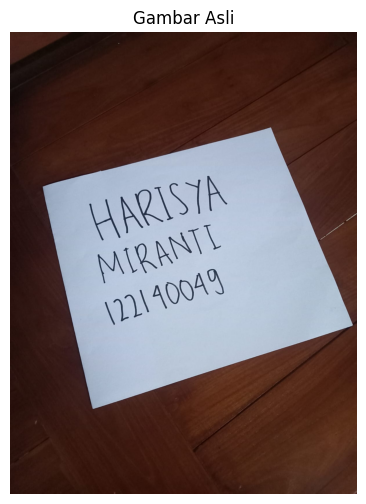

In [73]:
# Load gambar 
img_path_no5 = "assets_ws4/no5.jpg"  
img_no5 = cv2.imread(img_path_no5)

if img_no5 is None:
    raise FileNotFoundError(f"'{img_path_no5}' tidak ditemukan! Pastikan file ada.")

print(f"Gambar dimuat: {img_no5.shape[1]}x{img_no5.shape[0]} piksel")
plt.figure(figsize=(8, 6))
plt.imshow(cv2.cvtColor(img_no5, cv2.COLOR_BGR2RGB))
plt.title("Gambar Asli")
plt.axis('off')
plt.show()

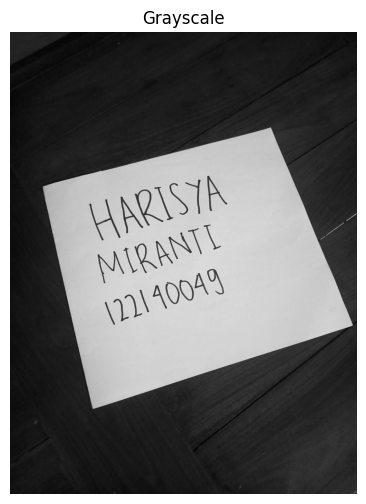

In [74]:
# Konversi ke grayscale
gray = cv2.cvtColor(img_no5, cv2.COLOR_RGB2GRAY)

# Tampilkan
plt.figure(figsize=(8, 6))
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis('off')
plt.show()

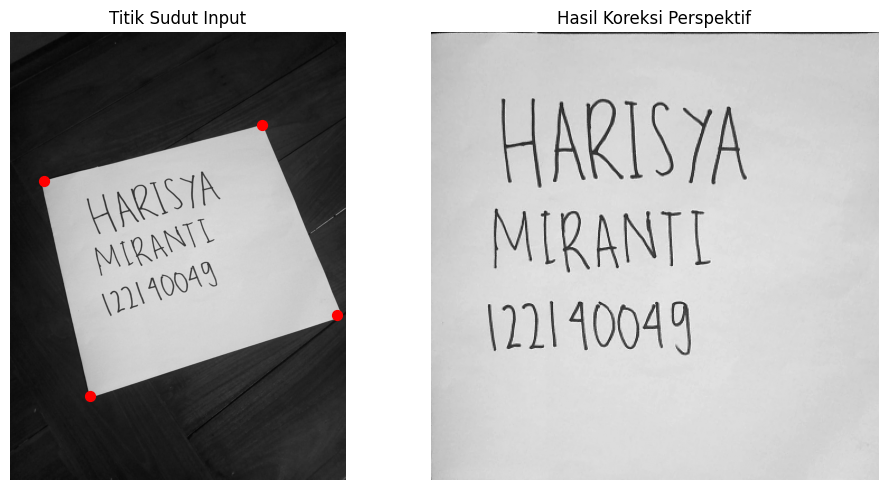

In [ ]:
# Koordinat sudut kertas
# Format: [x, y] — urutan: kiri atas, kanan atas, kanan bawah, kiri bawah
src_points = np.array([
    [120, 530],   # kiri atas
    [900, 330],   # kanan atas
    [1170, 1010],   # kanan bawah
    [285, 1300]    # kiri bawah
], dtype=np.float32)

# Ukuran output (lebar x tinggi) 
width = 400
height = 400
dst_points = np.array([
    [0, 0],
    [width, 0],
    [width, height],
    [0, height]
], dtype=np.float32)

# Hitung matriks homografi
M = cv2.getPerspectiveTransform(src_points, dst_points)

# Terapkan transformasi perspektif
warped = cv2.warpPerspective(gray, M, (width, height))

# Tampilkan hasil koreksi perspektif
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(gray, cmap='gray')
plt.scatter(src_points[:, 0], src_points[:, 1], c='red', s=50)
plt.title("Titik Sudut Input")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(warped, cmap='gray')
plt.title("Hasil Koreksi Perspektif")
plt.axis('off')

plt.tight_layout()
plt.show()

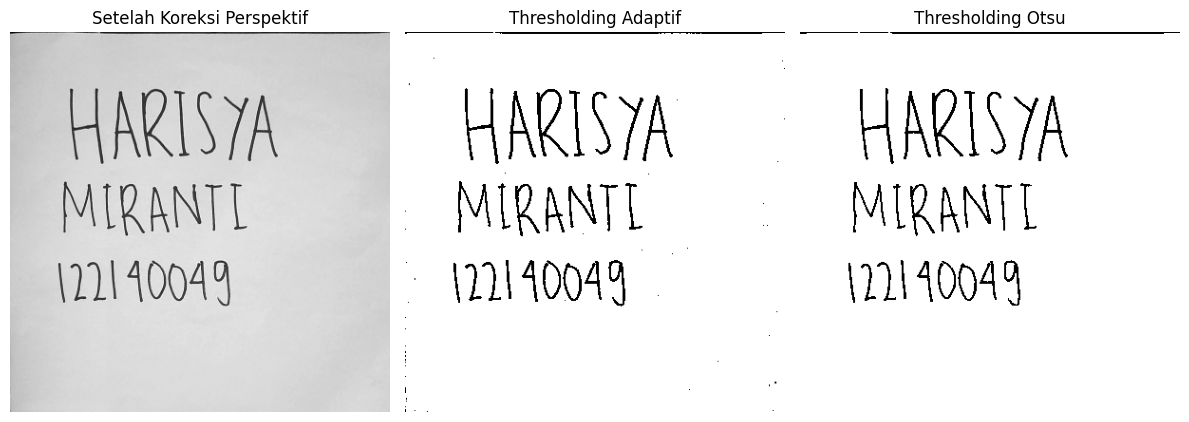

True

In [76]:
# Thresholding Otsu
_, otsu_thresh = cv2.threshold(warped, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Thresholding Adaptif (untuk perbandingan)
adaptive_thresh = cv2.adaptiveThreshold(
    warped, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    blockSize=15, C=5
)

# Tampilkan perbandingan
plt.figure(figsize=(12, 5))

plt.subplot(1, 3, 1)
plt.imshow(warped, cmap='gray')
plt.title("Setelah Koreksi Perspektif")
plt.axis('off')

plt.subplot(1, 3, 2)
plt.imshow(adaptive_thresh, cmap='gray')
plt.title("Thresholding Adaptif")
plt.axis('off')

plt.subplot(1, 3, 3)
plt.imshow(otsu_thresh, cmap='gray')
plt.title("Thresholding Otsu")
plt.axis('off')

plt.tight_layout()
plt.show()

# simpan hasil perbandingan
cv2.imwrite('results_ws4/warped_image.jpg', warped)
cv2.imwrite('results_ws4/adaptive_threshold.jpg', adaptive_thresh)
cv2.imwrite('results_ws4/otsu_threshold.jpg', otsu_thresh)


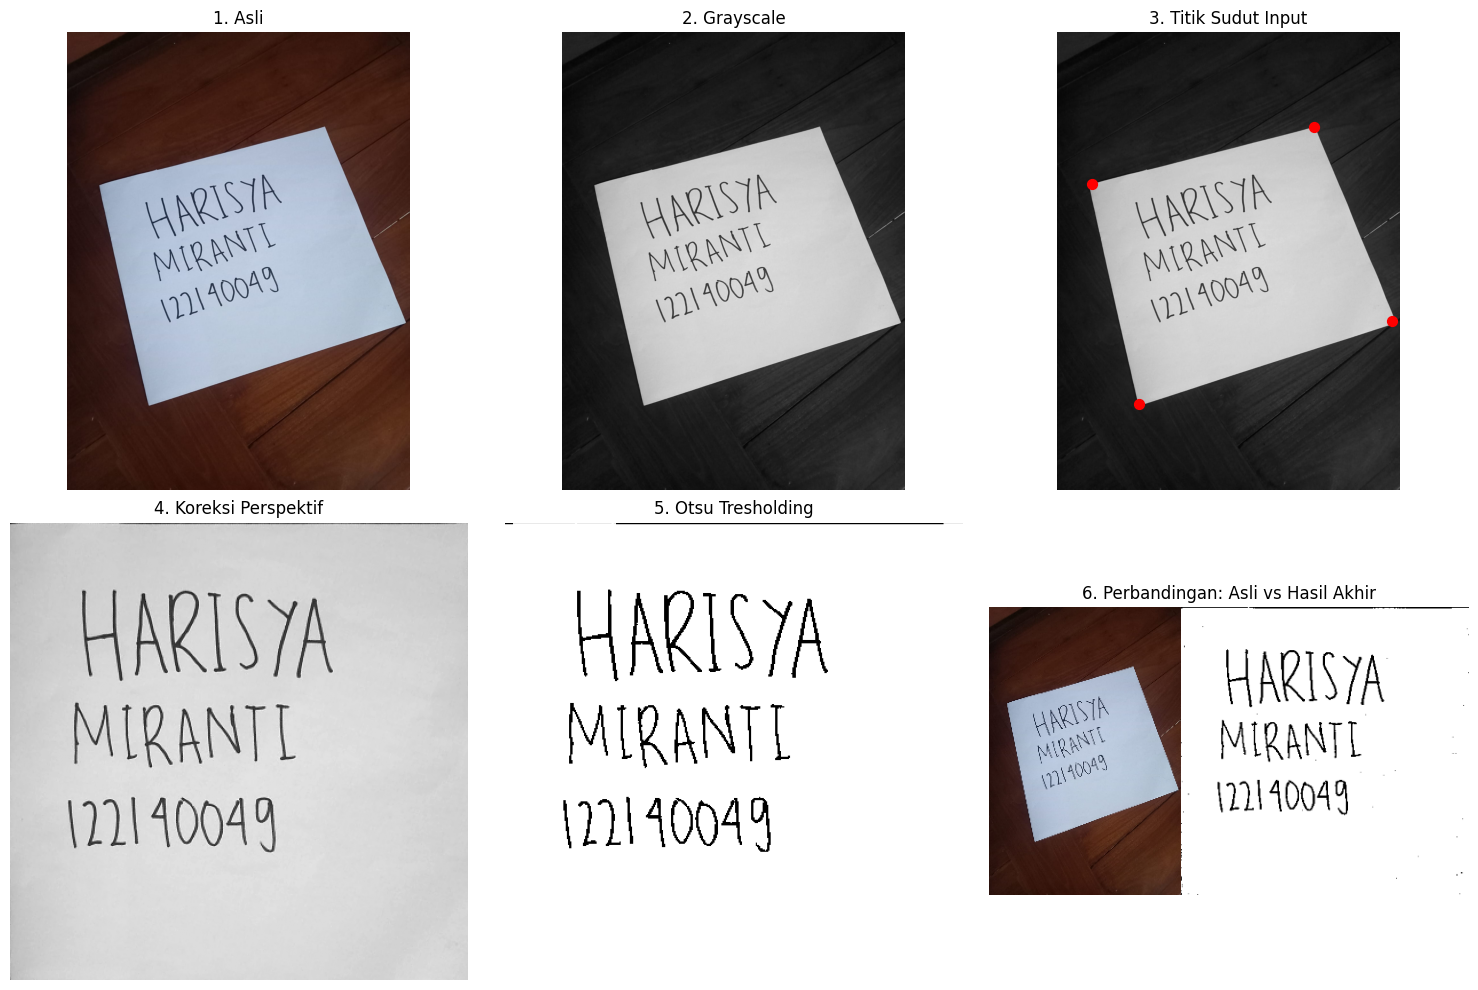

In [77]:
plt.figure(figsize=(15, 10))

# 1. Asli
plt.subplot(2, 3, 1)
plt.imshow(cv2.cvtColor(img_no5, cv2.COLOR_BGR2RGB))
plt.title("1. Asli", fontsize=12)
plt.axis('off')

# 2. Grayscale
plt.subplot(2, 3, 2)
plt.imshow(gray, cmap='gray')
plt.title("2. Grayscale", fontsize=12)
plt.axis('off')

# 3. Titik Sudut 
plt.subplot(2, 3, 3)
plt.imshow(gray, cmap='gray')
plt.scatter(src_points[:, 0], src_points[:, 1], c='red', s=50)
plt.title("3. Titik Sudut Input", fontsize=12)
plt.axis('off')

# 4. Koreksi Perspektif
plt.subplot(2, 3, 4)
plt.imshow(warped, cmap='gray')
plt.title("4. Koreksi Perspektif", fontsize=12)
plt.axis('off')

# 5. Hasil Thresholding
plt.subplot(2, 3, 5)
plt.imshow(otsu_thresh, cmap='gray')
plt.title("5. Otsu Tresholding", fontsize=12)
plt.axis('off')

# 6. Perbandingan Akhir (Original vs Final)
plt.subplot(2, 3, 6)
final_rgb = cv2.cvtColor(adaptive_thresh, cv2.COLOR_GRAY2BGR)
comparison = np.hstack((cv2.resize(img_no5, (200, 300)), cv2.resize(final_rgb, (300, 300))))
plt.imshow(cv2.cvtColor(comparison, cv2.COLOR_BGR2RGB))
plt.title("6. Perbandingan: Asli vs Hasil Akhir", fontsize=12)
plt.axis('off')

plt.tight_layout()
plt.show()

**penjelasan:**

Proses preprocessing dimulai dengan konversi ke grayscale, yang menghilangkan informasi warna berlebih dan memfokuskan pada intensitas cahaya, sehingga mempermudah analisis struktur teks dan latar belakang. Tahap kedua, koreksi perspektif menggunakan transformasi homografi, bertujuan untuk “meluruskan” objek datar (dalam hal ini kertas tulisan) yang sebelumnya terlihat miring karena diambil dari sudut pandang tidak ideal. Dengan menentukan empat titik sudut secara manual dan memetakan ulang ke bidang persegi panjang, citra menjadi lebih rapi dan mudah dibaca seolah-olah diambil dari atas secara langsung. Tahap terakhir, saya melakukan perbandingan thresholding adaptive dan Otsu. Saya lebih memilih thresholding Otsu, karena dalam tahap ini mengubah citra grayscale menjadi biner (hitam-putih) dengan cara otomatis menentukan nilai ambang optimal berdasarkan distribusi histogram intensitas. Ini sangat efektif ketika pencahayaan cukup merata, seperti pada gambar kertas ini, karena membuat teks hitam kontras kuat terhadap latar putih, tanpa noise berlebihan. Tiap tahapan ini memberikan output yang baik, mulai dari koreksi perspektif untuk memperbaiki geometri, sementara thresholding untuk memperkuat kontras sehingga kualitas visual meningkat drastis sehingga membuat teks jauh lebih jelas, rapi. 

### **Aturan Umum Pengerjaan**

* Kerjakan secara **mandiri**.
* Bantuan AI (seperti ChatGPT, Copilot, dsb.) diperbolehkan **dengan bukti percakapan** (screenshot / link / script percakapan).
* Jika mendapat bantuan teman, tuliskan nama dan NIM teman yang membantu.
* Plagiarisme akan dikenakan sanksi sesuai aturan akademik ITERA.
* Cantumkan seluruh **credit dan referensi** yang digunakan di bagian akhir notebook.
* Penjelasan setiap soal ditulis dalam **Markdown**, bukan di dalam komentar kode.

---

### **Aturan Pengumpulan**

* Semua file kerja Anda (notebook `.ipynb`, gambar, dan hasil) **wajib diunggah ke GitHub repository tugas sebelumnya**.

  * Gunakan struktur folder berikut di dalam repo Anda:

    ```
    /Nama_NIM_Repo/ # Nama repo sebelumnya
      ├── assets_ws4/     # berisi semua gambar atau video asli (input)
      ├── results_ws4/    # berisi semua hasil modifikasi dan output
      ├── worksheet4.ipynb
      └── NIM_Worksheet4.pdf
    ```
* File yang dikumpulkan ke **Tally** hanya berupa **hasil PDF** dari notebook Anda, dengan format nama:

  ```
  NIM_Worksheet4.pdf
  ```
* Pastikan notebook telah dijalankan penuh sebelum diekspor ke PDF.
* Sertakan tautan ke repository GitHub Anda di bagian atas notebook atau di halaman pertama PDF.

---


> Worksheet 4 ini bertujuan mengasah pemahaman Anda tentang manipulasi citra digital secara praktis. Gunakan kreativitas Anda untuk menghasilkan hasil visual yang menarik dan penjelasan konseptual yang jelas. 

**Referensi:**

- https://chatgpt.com/share/691b23bd-c734-8013-85da-c17e2630faae
- https://i.sstatic.net/aGdBV.jpg